# Taller Final – Parte de Clasificación
## Predicción y Clasificación en la Industria Azucarera

**Objetivo del notebook:** desarrollar, validar e interpretar modelos de **clasificación** para categorizar el desempeño de:
- **TCH** en niveles: bajo, medio y alto
- **sacarosa** en niveles: bajo, medio y alto

## 1. Entender el problema

Queremos transformar dos variables continuas en **categorías**:

- `TCH`  → bajo / medio / alto
- `sacarosa` → bajo / medio / alto

Luego entrenaremos modelos para predecir esas categorías usando las demás variables del dataset.

### Decisión metodológica
En este notebook los cortes se harán con **percentiles**:
- Bajo: valores hasta el percentil 33
- Medio: valores entre percentil 33 y 66
- Alto: valores por encima del percentil 66


## 2. Importar librerías

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score,
    make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

## 3. Cargar los datos

In [3]:
path = "../data/raw/BD_IPSA_1940.xlsx"

df = pd.read_excel(path)
df.head()

,Unnamed: 0,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


In [4]:
print("Dimensiones:", df.shape)
display(df.head(3))
display(df.info())
display(df.describe(include="all").T.head(20))

Dimensiones: (2187, 21)


,Unnamed: 0,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3


<class 'pandas.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2187 non-null   int64  
 1   NOME            2187 non-null   str    
 2   FAZ             2187 non-null   int64  
 3   TAL             2187 non-null   object 
 4   tipocorte       2187 non-null   str    
 5   variedad        2187 non-null   str    
 6   madurada        2187 non-null   str    
 7   producto        2187 non-null   str    
 8   dosismad        2187 non-null   float64
 9   semsmad         2187 non-null   float64
 10  edad            2187 non-null   float64
 11  cortes          2187 non-null   int64  
 12  me              2187 non-null   float64
 13  vejez           2187 non-null   float64
 14  sacarosa        2187 non-null   float64
 15  mes             2187 non-null   int64  
 16  periodo         2187 non-null   int64  
 17  TCH             2187 non-null   int64  
 18 

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,2187.0,NaN,NaN,NaN,2126.50663,1228.561661,11.0,1038.0,2219.0,3223.5,4222.0
NOME,2187,285,SAN MIGUEL CARVAJAL,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAZ,2187.0,NaN,NaN,NaN,80588.332876,572.818299,80100.0,80222.0,80396.0,80660.0,82519.0
TAL,2187.0,273.0,1.0,258.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipocorte,2187,1,Mecanizado Verde,2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variedad,2187,1,CC01-1940,2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
madurada,2187,1,SI,2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
producto,2187,1,BONUS 250 EC REGULADOR FISIOLÓGICO,2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dosismad,2187.0,NaN,NaN,NaN,0.993278,0.309096,0.0,0.8,1.0,1.2,9.0
semsmad,2187.0,NaN,NaN,NaN,9.164838,3.441579,-1.6,7.1,8.7,10.6,45.0


## 4. Comprender las variables del negocio

- `TCH` representa toneladas de caña por hectárea.
- `sacarosa` representa el porcentaje o cantidad de sacarosa en el cultivo.
- Existen variables de contexto agronómico como variedad, edad, lluvias, cortes, vejez, maduración y porcentaje de diatrea.

## 5. EDA inicial
### 5.1 Normalizar nombres de columnas
Esto ayuda a evitar errores por espacios, mayúsculas o caracteres especiales.

In [5]:
def normalizar_columna(c):
    c = str(c).strip().lower()
    c = c.replace("%", "pct")
    c = c.replace(".", "_")
    c = c.replace(" ", "_")
    c = c.replace("ñ", "n")
    c = c.replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")
    c = c.replace("__", "_")
    return c

df.columns = [normalizar_columna(c) for c in df.columns]
print(df.columns.tolist())

['unnamed:_0', 'nome', 'faz', 'tal', 'tipocorte', 'variedad', 'madurada', 'producto', 'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez', 'sacarosa', 'mes', 'periodo', 'tch', 'lluvias', 'grupo_tenencia', 'pct_diatrea']


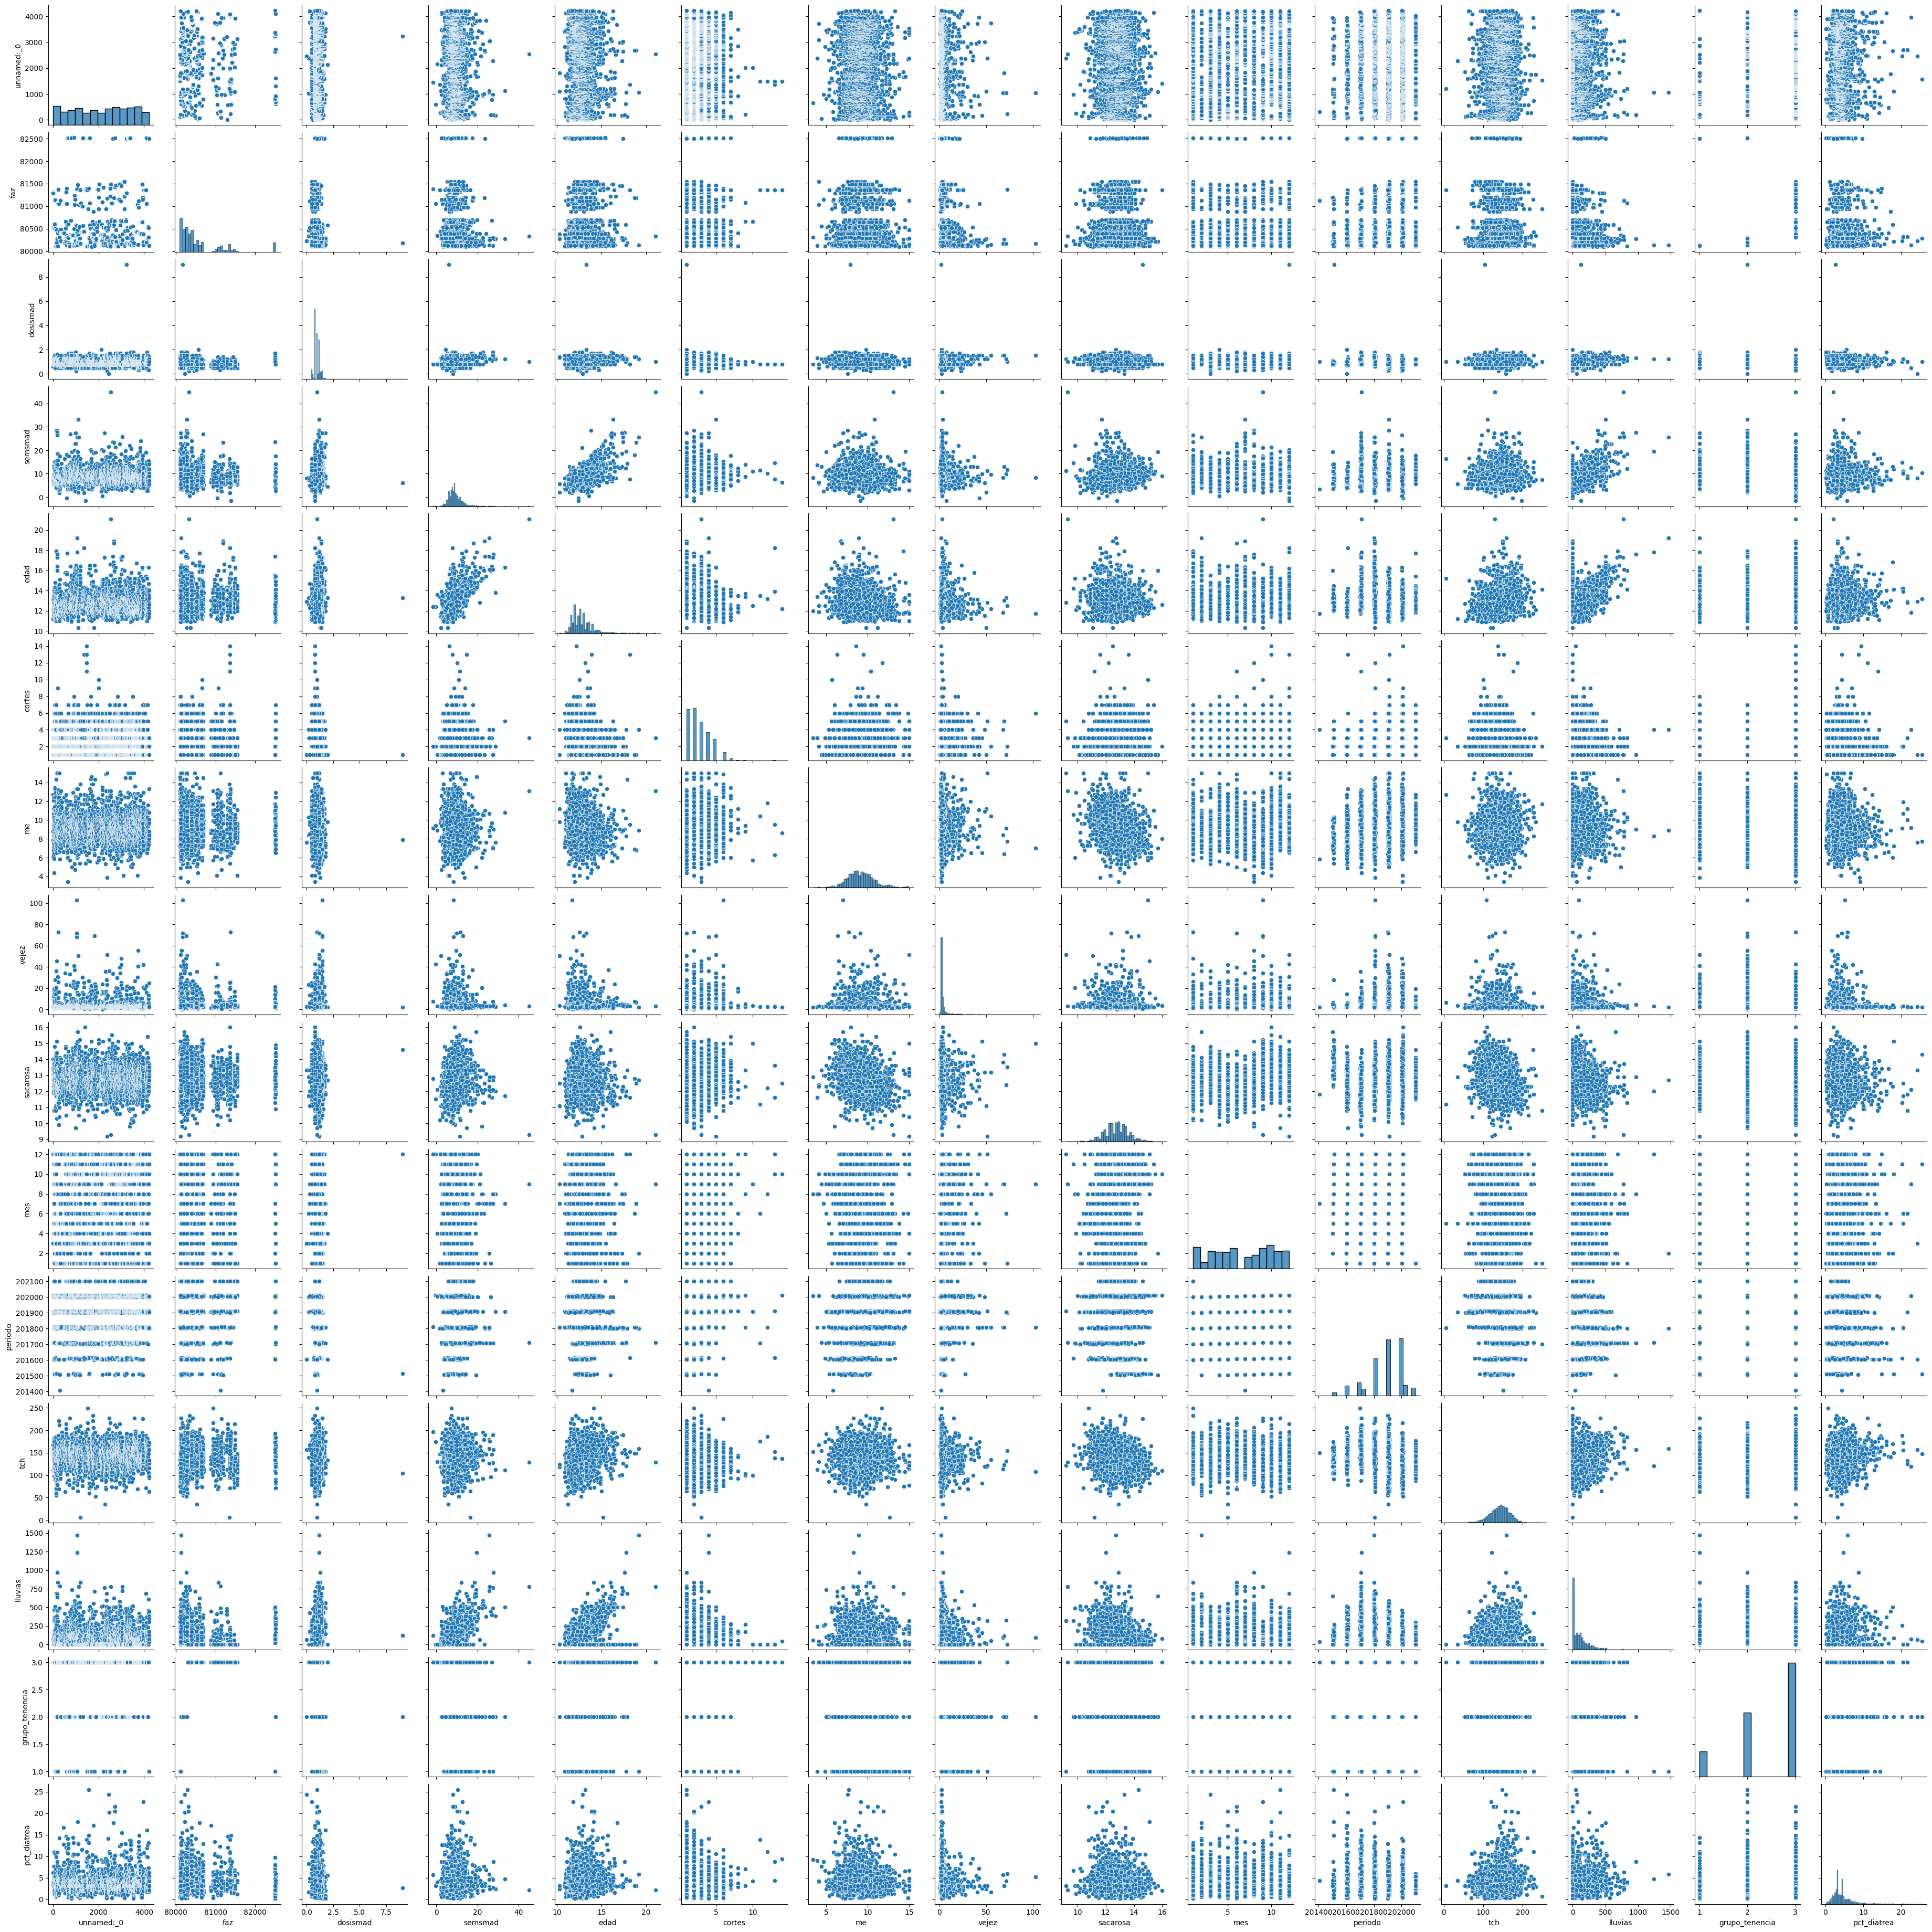

In [6]:
sns.pairplot(df)
plt.show()

### 5.2 Identificar variables objetivo y revisar que existan

In [7]:
COL_TCH = "tch"
COL_SACAROSA = "sacarosa"

df[[COL_TCH, COL_SACAROSA]].describe()


print(df.columns.tolist())


['unnamed:_0', 'nome', 'faz', 'tal', 'tipocorte', 'variedad', 'madurada', 'producto', 'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez', 'sacarosa', 'mes', 'periodo', 'tch', 'lluvias', 'grupo_tenencia', 'pct_diatrea']


### 5.3 Valores nulos

In [8]:
nulos = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("nulos")
)
nulos["pct_nulos"] = (nulos["nulos"] / len(df) * 100).round(2)
display(nulos.head(20))

,nulos,pct_nulos
unnamed:_0,0,0.0
cortes,0,0.0
grupo_tenencia,0,0.0
lluvias,0,0.0
tch,0,0.0
periodo,0,0.0
mes,0,0.0
sacarosa,0,0.0
vejez,0,0.0
me,0,0.0


### 5.4 Distribución de las variables continuas objetivo

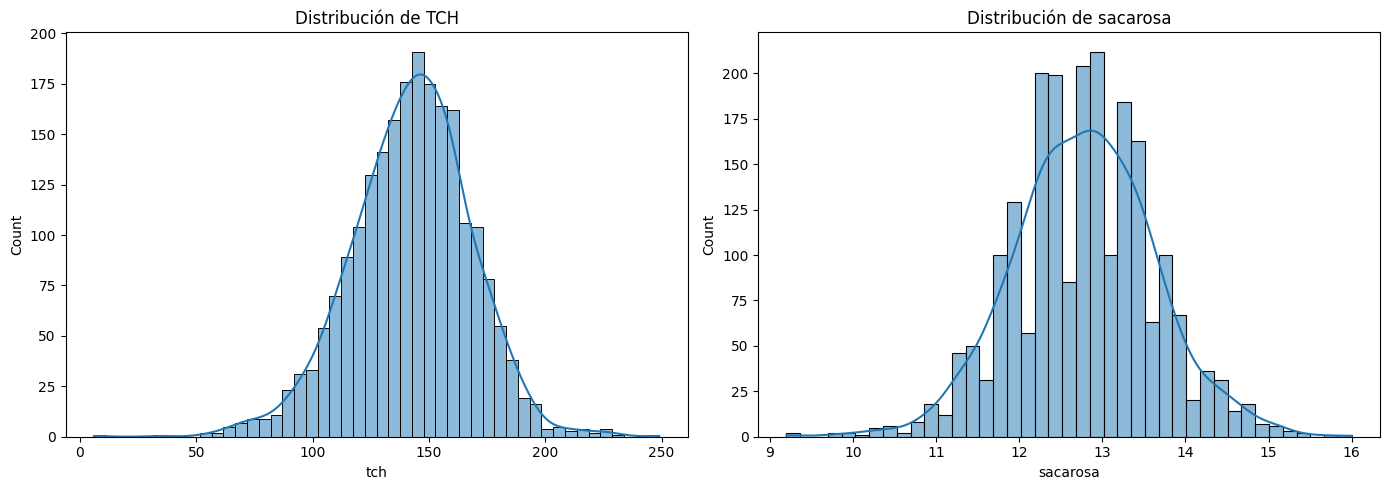

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[COL_TCH].dropna(), kde=True, ax=ax[0])
ax[0].set_title("Distribución de TCH")

sns.histplot(df[COL_SACAROSA].dropna(), kde=True, ax=ax[1])
ax[1].set_title("Distribución de sacarosa")

plt.tight_layout()
plt.show()

### 5.5 Outliers visuales

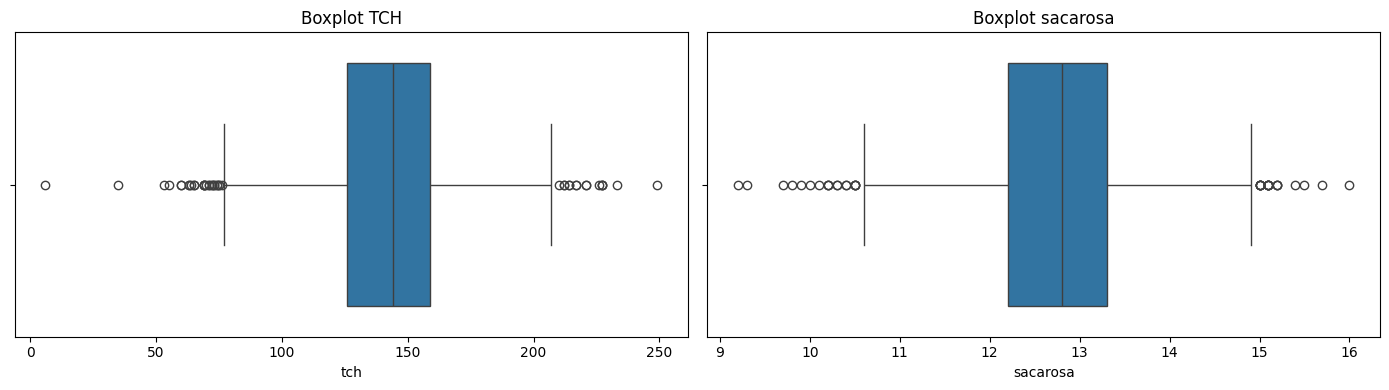

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=df[COL_TCH], ax=ax[0])
ax[0].set_title("Boxplot TCH")

sns.boxplot(x=df[COL_SACAROSA], ax=ax[1])
ax[1].set_title("Boxplot sacarosa")

plt.tight_layout()
plt.show()

### 5.6 Correlaciones entre variables numéricas

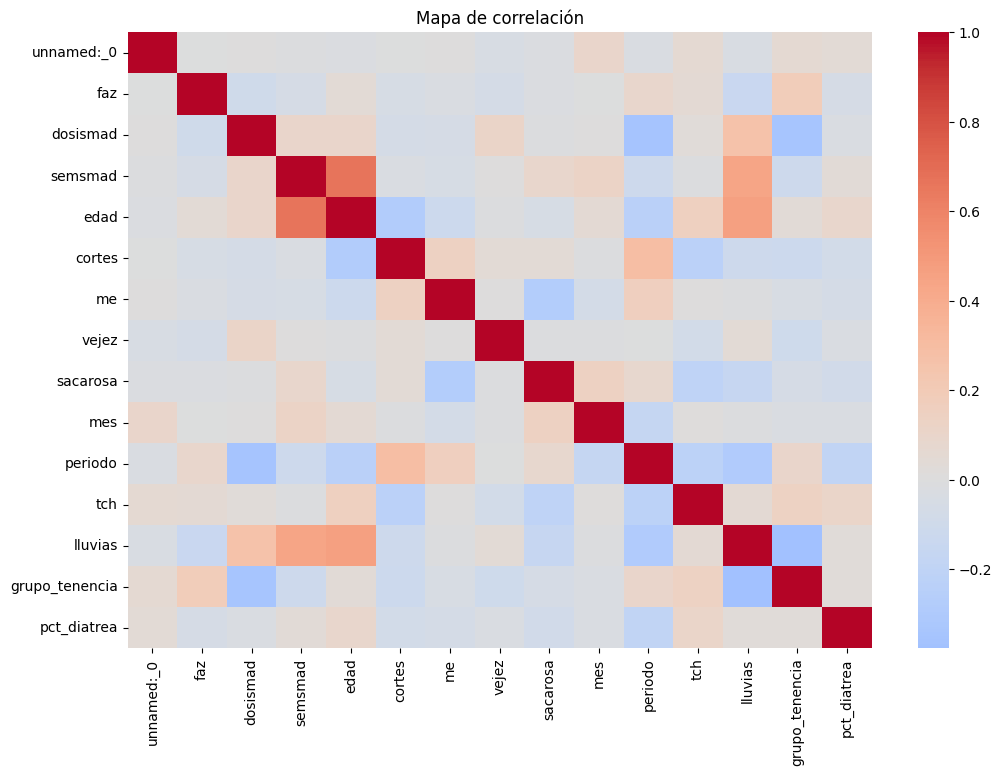

In [11]:
numericas = df.select_dtypes(include=np.number).columns.tolist()

if len(numericas) > 1:
    plt.figure(figsize=(12, 8))
    corr = df[numericas].corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Mapa de correlación")
    plt.show()
else:
    print("No hay suficientes variables numéricas para calcular correlación.")

## 6. Creación de categorías de clasificación

Usaremos percentiles 33 y 66 para crear tres clases:
- `bajo`
- `medio`
- `alto`

In [12]:
def crear_categoria_por_percentiles(serie, etiquetas=("bajo", "medio", "alto")):
    q1 = serie.quantile(0.33)
    q2 = serie.quantile(0.66)

    bins = [-np.inf, q1, q2, np.inf]
    cat = pd.cut(serie, bins=bins, labels=etiquetas, include_lowest=True)
    return cat, q1, q2

df["clase_tch"], q1_tch, q2_tch = crear_categoria_por_percentiles(df[COL_TCH])
df["clase_sacarosa"], q1_sac, q2_sac = crear_categoria_por_percentiles(df[COL_SACAROSA])

print("Cortes TCH:", round(q1_tch, 4), round(q2_tch, 4))
print("Cortes sacarosa:", round(q1_sac, 4), round(q2_sac, 4))

Cortes TCH: 132.38 153.0
Cortes sacarosa: 12.4 13.1


In [13]:
display(df["clase_tch"].value_counts(dropna=False))
display(df["clase_sacarosa"].value_counts(dropna=False))

clase_tch
medio    737
alto     728
bajo     722
Name: count, dtype: int64

clase_sacarosa
bajo     761
alto     716
medio    710
Name: count, dtype: int64

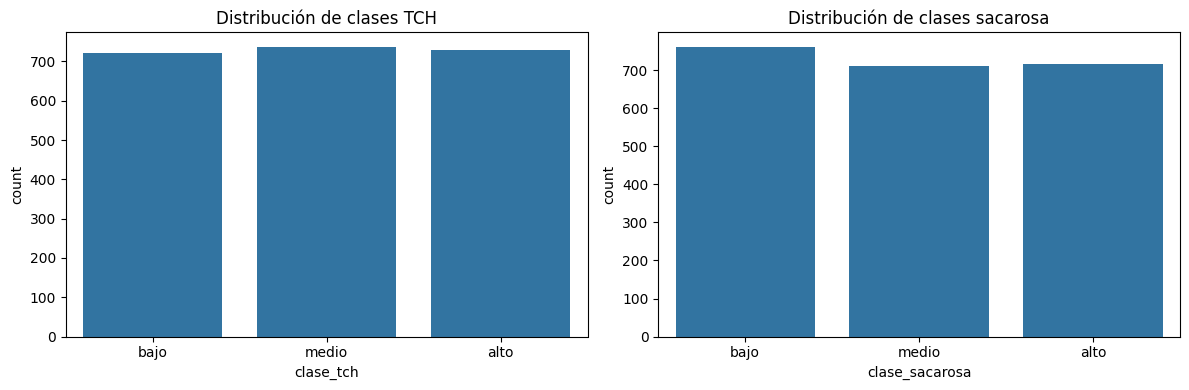

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="clase_tch", data=df, ax=ax[0], order=["bajo", "medio", "alto"])
ax[0].set_title("Distribución de clases TCH")

sns.countplot(x="clase_sacarosa", data=df, ax=ax[1], order=["bajo", "medio", "alto"])
ax[1].set_title("Distribución de clases sacarosa")

plt.tight_layout()
plt.show()

## 7. Limpieza y selección de variables

### Decisiones importantes
1. Eliminaremos columnas que:
   - sean identificadores puros,
   - tengan demasiados nulos,
   - o filtren información del objetivo.

2. No usaremos `TCH` para predecir `clase_tch` ni `sacarosa` para predecir `clase_sacarosa`, porque eso sería fuga de información (**data leakage**).

In [15]:

columnas_id_probables = [c for c in df.columns if c in ["nome", "faz", "tal"]]

# columnas con demasiados nulos
umbral_nulos = 0.40
columnas_muchos_nulos = nulos[nulos["pct_nulos"] > umbral_nulos * 100].index.tolist()

print("Columnas ID probables:", columnas_id_probables)
print("Columnas con muchos nulos:", columnas_muchos_nulos)

Columnas ID probables: ['nome', 'faz', 'tal']
Columnas con muchos nulos: []


## 8. Funciones reutilizables para modelado

In [16]:
def preparar_datos_para_objetivo(df_base, target_col, cols_a_excluir_extra=None):
    df_model = df_base.copy()

    cols_a_excluir_extra = cols_a_excluir_extra or []

    excluir = set(columnas_id_probables + columnas_muchos_nulos + cols_a_excluir_extra + [target_col])
    features = [c for c in df_model.columns if c not in excluir]

    X = df_model[features].copy()
    y = df_model[target_col].copy()

    # quitar filas sin etiqueta
    mask = y.notna()
    X = X.loc[mask].copy()
    y = y.loc[mask].copy()

    return X, y

def construir_preprocesador(X):
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

    return preprocessor, num_cols, cat_cols

def evaluar_modelo(y_true, y_pred, titulo="Modelo"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f"=== {titulo} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Kappa    : {kappa:.4f}")
    print()
    print("Reporte de clasificación")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "kappa": kappa
    }

def validacion_cruzada(pipe, X, y, cv=5):
    scoring = {
        "accuracy": "accuracy",
        "precision_weighted": "precision_weighted",
        "recall_weighted": "recall_weighted",
        "f1_weighted": "f1_weighted",
        "kappa": make_scorer(cohen_kappa_score)
    }

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    res = cross_validate(pipe, X, y, cv=skf, scoring=scoring, n_jobs=-1)

    resumen = pd.DataFrame(res).mean().to_frame("promedio")
    return resumen

## 9. Modelo 1: Clasificación de niveles de TCH

In [17]:
X_tch, y_tch = preparar_datos_para_objetivo(
    df,
    target_col="clase_tch",
    cols_a_excluir_extra=[COL_TCH, COL_SACAROSA, "clase_sacarosa"]
)

print("X_tch:", X_tch.shape)
print("y_tch:", y_tch.shape)
display(y_tch.value_counts())

X_tch: (2187, 16)
y_tch: (2187,)


clase_tch
medio    737
alto     728
bajo     722
Name: count, dtype: int64

In [18]:
X_train_tch, X_test_tch, y_train_tch, y_test_tch = train_test_split(
    X_tch, y_tch,
    test_size=0.2,
    random_state=42,
    stratify=y_tch
)

pre_tch, num_tch, cat_tch = construir_preprocesador(X_train_tch)

print("Variables numéricas:", num_tch)
print("Variables categóricas:", cat_tch)

Variables numéricas: ['unnamed:_0', 'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez', 'mes', 'periodo', 'lluvias', 'grupo_tenencia', 'pct_diatrea']
Variables categóricas: ['tipocorte', 'variedad', 'madurada', 'producto']


### 9.1 Regresión logística multinomial con regularización

In [19]:
pipe_log_tch = Pipeline([
    ("prep", pre_tch),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        C=1.0
    ))
])

pipe_log_tch.fit(X_train_tch, y_train_tch)
pred_log_tch = pipe_log_tch.predict(X_test_tch)

metricas_log_tch = evaluar_modelo(y_test_tch, pred_log_tch, "Logistic Regression - TCH")

=== Logistic Regression - TCH ===
Accuracy : 0.4475
Precision: 0.4415
Recall   : 0.4475
F1-score : 0.4392
Kappa    : 0.1714

Reporte de clasificación
              precision    recall  f1-score   support

        alto       0.47      0.62      0.53       146
        bajo       0.48      0.43      0.46       144
       medio       0.37      0.30      0.33       148

    accuracy                           0.45       438
   macro avg       0.44      0.45      0.44       438
weighted avg       0.44      0.45      0.44       438



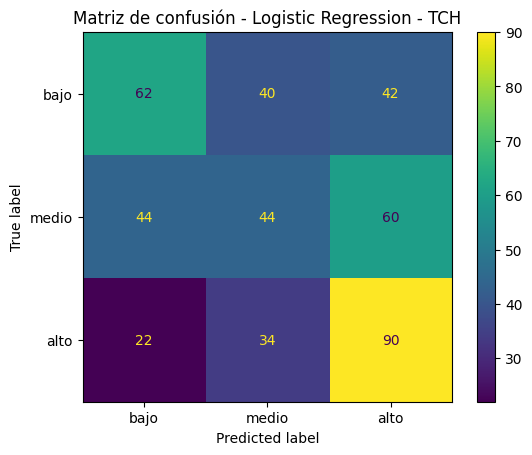

In [20]:
cm = confusion_matrix(y_test_tch, pred_log_tch, labels=["bajo", "medio", "alto"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["bajo", "medio", "alto"])
disp.plot()
plt.title("Matriz de confusión - Logistic Regression - TCH")
plt.show()

### 9.2 KNN

In [21]:
pipe_knn_tch = Pipeline([
    ("prep", pre_tch),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

pipe_knn_tch.fit(X_train_tch, y_train_tch)
pred_knn_tch = pipe_knn_tch.predict(X_test_tch)

metricas_knn_tch = evaluar_modelo(y_test_tch, pred_knn_tch, "KNN - TCH")

=== KNN - TCH ===
Accuracy : 0.4749
Precision: 0.4697
Recall   : 0.4749
F1-score : 0.4686
Kappa    : 0.2123

Reporte de clasificación
              precision    recall  f1-score   support

        alto       0.51      0.64      0.57       146
        bajo       0.51      0.45      0.48       144
       medio       0.39      0.34      0.36       148

    accuracy                           0.47       438
   macro avg       0.47      0.48      0.47       438
weighted avg       0.47      0.47      0.47       438



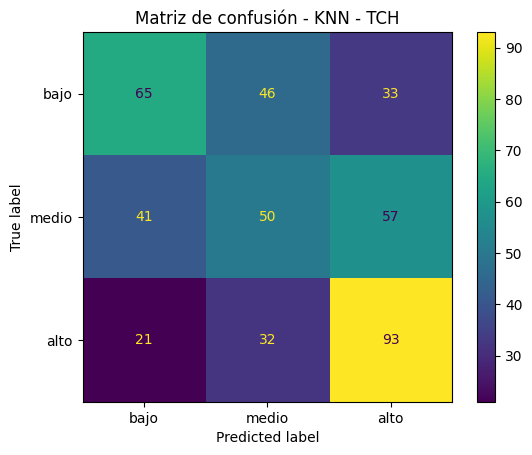

In [22]:
cm = confusion_matrix(y_test_tch, pred_knn_tch, labels=["bajo", "medio", "alto"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["bajo", "medio", "alto"])
disp.plot()
plt.title("Matriz de confusión - KNN - TCH")
plt.show()

### 9.3 Validación cruzada para TCH

In [23]:
print("Validación cruzada - Logistic Regression (TCH)")
display(validacion_cruzada(pipe_log_tch, X_tch, y_tch, cv=5))

print("Validación cruzada - KNN (TCH)")
display(validacion_cruzada(pipe_knn_tch, X_tch, y_tch, cv=5))

Validación cruzada - Logistic Regression (TCH)


,promedio
fit_time,0.014072
score_time,0.010848
test_accuracy,0.452686
test_precision_weighted,0.445842
test_recall_weighted,0.452686
test_f1_weighted,0.443421
test_kappa,0.179600


Validación cruzada - KNN (TCH)


,promedio
fit_time,0.010255
score_time,0.028606
test_accuracy,0.472795
test_precision_weighted,0.467414
test_recall_weighted,0.472795
test_f1_weighted,0.465083
test_kappa,0.209495


## 10. Modelo 2: Clasificación de niveles de sacarosa

In [24]:
X_sac, y_sac = preparar_datos_para_objetivo(
    df,
    target_col="clase_sacarosa",
    cols_a_excluir_extra=[COL_TCH, COL_SACAROSA, "clase_tch"]
)

print("X_sac:", X_sac.shape)
print("y_sac:", y_sac.shape)
display(y_sac.value_counts())

X_sac: (2187, 16)
y_sac: (2187,)


clase_sacarosa
bajo     761
alto     716
medio    710
Name: count, dtype: int64

In [25]:
X_train_sac, X_test_sac, y_train_sac, y_test_sac = train_test_split(
    X_sac, y_sac,
    test_size=0.2,
    random_state=42,
    stratify=y_sac
)

pre_sac, num_sac, cat_sac = construir_preprocesador(X_train_sac)

print("Variables numéricas:", num_sac)
print("Variables categóricas:", cat_sac)

Variables numéricas: ['unnamed:_0', 'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez', 'mes', 'periodo', 'lluvias', 'grupo_tenencia', 'pct_diatrea']
Variables categóricas: ['tipocorte', 'variedad', 'madurada', 'producto']


### 10.1 Regresión logística multinomial con regularización

In [26]:
pipe_log_sac = Pipeline([
    ("prep", pre_sac),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        C=1.0
    ))
])

pipe_log_sac.fit(X_train_sac, y_train_sac)
pred_log_sac = pipe_log_sac.predict(X_test_sac)

metricas_log_sac = evaluar_modelo(y_test_sac, pred_log_sac, "Logistic Regression - Sacarosa")

=== Logistic Regression - Sacarosa ===
Accuracy : 0.4817
Precision: 0.4620
Recall   : 0.4817
F1-score : 0.4604
Kappa    : 0.2214

Reporte de clasificación
              precision    recall  f1-score   support

        alto       0.48      0.66      0.56       143
        bajo       0.55      0.58      0.56       153
       medio       0.35      0.20      0.25       142

    accuracy                           0.48       438
   macro avg       0.46      0.48      0.46       438
weighted avg       0.46      0.48      0.46       438



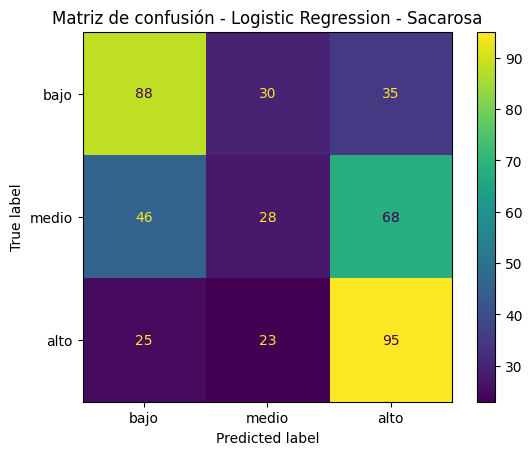

In [27]:
cm = confusion_matrix(y_test_sac, pred_log_sac, labels=["bajo", "medio", "alto"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["bajo", "medio", "alto"])
disp.plot()
plt.title("Matriz de confusión - Logistic Regression - Sacarosa")
plt.show()

### 10.2 KNN

In [28]:
pipe_knn_sac = Pipeline([
    ("prep", pre_sac),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

pipe_knn_sac.fit(X_train_sac, y_train_sac)
pred_knn_sac = pipe_knn_sac.predict(X_test_sac)

metricas_knn_sac = evaluar_modelo(y_test_sac, pred_knn_sac, "KNN - Sacarosa")

=== KNN - Sacarosa ===
Accuracy : 0.5046
Precision: 0.4953
Recall   : 0.5046
F1-score : 0.4953
Kappa    : 0.2567

Reporte de clasificación
              precision    recall  f1-score   support

        alto       0.53      0.67      0.59       143
        bajo       0.57      0.54      0.55       153
       medio       0.39      0.30      0.34       142

    accuracy                           0.50       438
   macro avg       0.49      0.50      0.49       438
weighted avg       0.50      0.50      0.50       438



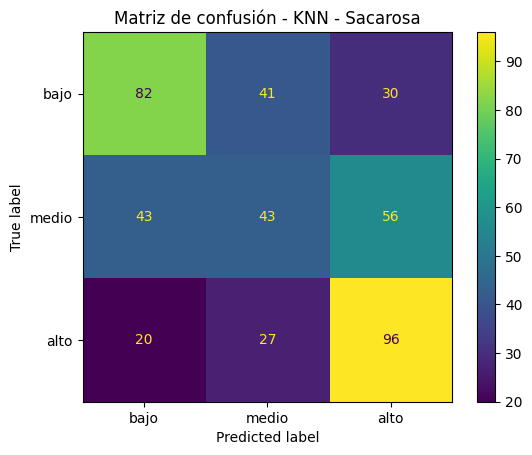

In [29]:
cm = confusion_matrix(y_test_sac, pred_knn_sac, labels=["bajo", "medio", "alto"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["bajo", "medio", "alto"])
disp.plot()
plt.title("Matriz de confusión - KNN - Sacarosa")
plt.show()

### 10.3 Validación cruzada para sacarosa

In [30]:
print("Validación cruzada - Logistic Regression (Sacarosa)")
display(validacion_cruzada(pipe_log_sac, X_sac, y_sac, cv=5))

print("Validación cruzada - KNN (Sacarosa)")
display(validacion_cruzada(pipe_knn_sac, X_sac, y_sac, cv=5))

Validación cruzada - Logistic Regression (Sacarosa)


,promedio
fit_time,0.011724
score_time,0.008988
test_accuracy,0.461364
test_precision_weighted,0.444951
test_recall_weighted,0.461364
test_f1_weighted,0.445143
test_kappa,0.189746


Validación cruzada - KNN (Sacarosa)


,promedio
fit_time,0.010656
score_time,0.015154
test_accuracy,0.483314
test_precision_weighted,0.471971
test_recall_weighted,0.483314
test_f1_weighted,0.473792
test_kappa,0.224123


## 11. Ajuste de hiperparámetros

Aquí haremos una búsqueda simple para mejorar ambos modelos.

In [31]:
param_grid_log = {
    "model__C": [0.01, 0.1, 1, 5, 10]
}

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["minkowski"]
}

### 11.1 Tuning para TCH

In [32]:
grid_log_tch = GridSearchCV(
    estimator=pipe_log_tch,
    param_grid=param_grid_log,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)
grid_log_tch.fit(X_train_tch, y_train_tch)

grid_knn_tch = GridSearchCV(
    estimator=pipe_knn_tch,
    param_grid=param_grid_knn,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)
grid_knn_tch.fit(X_train_tch, y_train_tch)

print("Mejores parámetros Logistic TCH:", grid_log_tch.best_params_)
print("Mejores parámetros KNN TCH:", grid_knn_tch.best_params_)

Mejores parámetros Logistic TCH: {'model__C': 0.1}
Mejores parámetros KNN TCH: {'model__metric': 'minkowski', 'model__n_neighbors': 11, 'model__weights': 'distance'}


In [33]:
best_log_tch = grid_log_tch.best_estimator_
best_knn_tch = grid_knn_tch.best_estimator_

pred_best_log_tch = best_log_tch.predict(X_test_tch)
pred_best_knn_tch = best_knn_tch.predict(X_test_tch)

res_best_log_tch = evaluar_modelo(y_test_tch, pred_best_log_tch, "Mejor Logistic Regression - TCH")
res_best_knn_tch = evaluar_modelo(y_test_tch, pred_best_knn_tch, "Mejor KNN - TCH")

=== Mejor Logistic Regression - TCH ===
Accuracy : 0.4475
Precision: 0.4411
Recall   : 0.4475
F1-score : 0.4392
Kappa    : 0.1714

Reporte de clasificación
              precision    recall  f1-score   support

        alto       0.47      0.62      0.53       146
        bajo       0.48      0.43      0.45       144
       medio       0.37      0.30      0.33       148

    accuracy                           0.45       438
   macro avg       0.44      0.45      0.44       438
weighted avg       0.44      0.45      0.44       438

=== Mejor KNN - TCH ===
Accuracy : 0.5114
Precision: 0.5087
Recall   : 0.5114
F1-score : 0.5091
Kappa    : 0.2670

Reporte de clasificación
              precision    recall  f1-score   support

        alto       0.57      0.64      0.60       146
        bajo       0.53      0.49      0.51       144
       medio       0.43      0.41      0.42       148

    accuracy                           0.51       438
   macro avg       0.51      0.51      0.51       4

### 11.2 Tuning para sacarosa

In [34]:
grid_log_sac = GridSearchCV(
    estimator=pipe_log_sac,
    param_grid=param_grid_log,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)
grid_log_sac.fit(X_train_sac, y_train_sac)

grid_knn_sac = GridSearchCV(
    estimator=pipe_knn_sac,
    param_grid=param_grid_knn,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)
grid_knn_sac.fit(X_train_sac, y_train_sac)

print("Mejores parámetros Logistic Sacarosa:", grid_log_sac.best_params_)
print("Mejores parámetros KNN Sacarosa:", grid_knn_sac.best_params_)

Mejores parámetros Logistic Sacarosa: {'model__C': 1}
Mejores parámetros KNN Sacarosa: {'model__metric': 'minkowski', 'model__n_neighbors': 15, 'model__weights': 'distance'}


In [35]:
best_log_sac = grid_log_sac.best_estimator_
best_knn_sac = grid_knn_sac.best_estimator_

pred_best_log_sac = best_log_sac.predict(X_test_sac)
pred_best_knn_sac = best_knn_sac.predict(X_test_sac)

res_best_log_sac = evaluar_modelo(y_test_sac, pred_best_log_sac, "Mejor Logistic Regression - Sacarosa")
res_best_knn_sac = evaluar_modelo(y_test_sac, pred_best_knn_sac, "Mejor KNN - Sacarosa")

=== Mejor Logistic Regression - Sacarosa ===
Accuracy : 0.4817
Precision: 0.4620
Recall   : 0.4817
F1-score : 0.4604
Kappa    : 0.2214

Reporte de clasificación
              precision    recall  f1-score   support

        alto       0.48      0.66      0.56       143
        bajo       0.55      0.58      0.56       153
       medio       0.35      0.20      0.25       142

    accuracy                           0.48       438
   macro avg       0.46      0.48      0.46       438
weighted avg       0.46      0.48      0.46       438

=== Mejor KNN - Sacarosa ===
Accuracy : 0.5205
Precision: 0.5135
Recall   : 0.5205
F1-score : 0.5138
Kappa    : 0.2810

Reporte de clasificación
              precision    recall  f1-score   support

        alto       0.56      0.69      0.61       143
        bajo       0.58      0.54      0.56       153
       medio       0.40      0.34      0.37       142

    accuracy                           0.52       438
   macro avg       0.51      0.52      0.

## 12. Interpretación del modelo
### Importancia aproximada de variables con regresión logística

La regresión logística regularizada permite inspeccionar coeficientes.
En un problema multiclase, cada clase tiene sus propios coeficientes.
Aquí mostraremos la magnitud promedio absoluta.

Top variables - Logistic TCH


,feature,importance
4,num__cortes,0.213450
8,num__periodo,0.139904
10,num__grupo_tenencia,0.118710
3,num__edad,0.097166
5,num__me,0.083997
11,num__pct_diatrea,0.081905
2,num__semsmad,0.081815
6,num__vejez,0.051980
0,num__unnamed:_0,0.040617
1,num__dosismad,0.031299


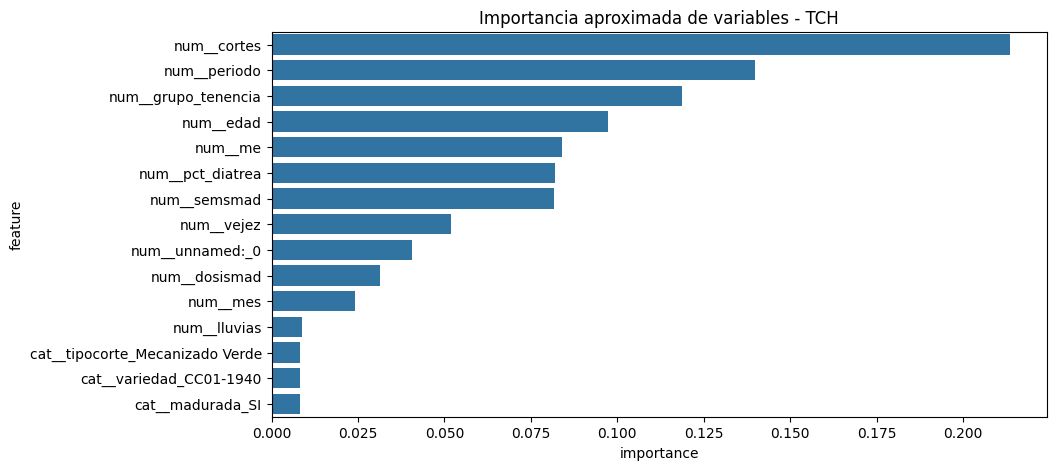

In [36]:
def importancia_logistica(pipe, top_n=15):
    prep = pipe.named_steps["prep"]
    model = pipe.named_steps["model"]

    feature_names = prep.get_feature_names_out()
    coef_abs = np.abs(model.coef_).mean(axis=0)

    imp = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": coef_abs
        })
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    return imp

print("Top variables - Logistic TCH")
imp_tch = importancia_logistica(best_log_tch, top_n=15)
display(imp_tch)

plt.figure(figsize=(10, 5))
sns.barplot(data=imp_tch, x="importance", y="feature")
plt.title("Importancia aproximada de variables - TCH")
plt.show()

Top variables - Logistic Sacarosa


,feature,importance
2,num__semsmad,0.236275
9,num__lluvias,0.234661
5,num__me,0.222471
7,num__mes,0.085629
10,num__grupo_tenencia,0.083991
11,num__pct_diatrea,0.080179
8,num__periodo,0.078381
6,num__vejez,0.063839
3,num__edad,0.063418
0,num__unnamed:_0,0.028111


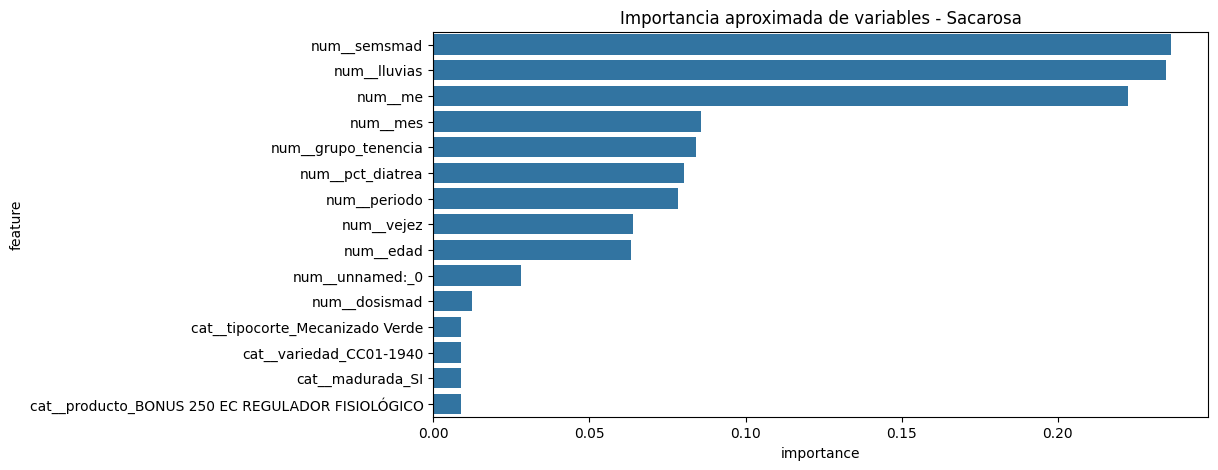

In [37]:
print("Top variables - Logistic Sacarosa")
imp_sac = importancia_logistica(best_log_sac, top_n=15)
display(imp_sac)

plt.figure(figsize=(10, 5))
sns.barplot(data=imp_sac, x="importance", y="feature")
plt.title("Importancia aproximada de variables - Sacarosa")
plt.show()

## 13. Comparación final de modelos

In [38]:
resumen = pd.DataFrame([
    {"objetivo": "TCH", "modelo": "Logistic", **res_best_log_tch},
    {"objetivo": "TCH", "modelo": "KNN", **res_best_knn_tch},
    {"objetivo": "Sacarosa", "modelo": "Logistic", **res_best_log_sac},
    {"objetivo": "Sacarosa", "modelo": "KNN", **res_best_knn_sac},
]).sort_values(["objetivo", "f1"], ascending=[True, False])

display(resumen)

,objetivo,modelo,accuracy,precision,recall,f1,kappa
3,Sacarosa,KNN,0.520548,0.513549,0.520548,0.513794,0.280962
2,Sacarosa,Logistic,0.481735,0.462047,0.481735,0.460375,0.221416
1,TCH,KNN,0.511416,0.508669,0.511416,0.509076,0.266997
0,TCH,Logistic,0.447489,0.441077,0.447489,0.439158,0.171375


## 14. Guía de interpretación para escribir el informe

Puedes redactar algo como esto:

### Sobre la creación de categorías
> Las variables continuas TCH y sacarosa fueron transformadas en tres niveles de desempeño usando percentiles 33 y 66. Esta estrategia permitió obtener clases razonablemente balanceadas y evitar umbrales arbitrarios.

### Sobre el preprocesamiento
> Se manejaron valores faltantes mediante imputación: mediana para variables numéricas y moda para variables categóricas. Las variables categóricas fueron codificadas con one-hot encoding. Para los modelos sensibles a escala, se aplicó estandarización.

### Sobre los modelos
> Se entrenaron dos algoritmos de clasificación: regresión logística multinomial con regularización y KNN. Ambos fueron evaluados mediante holdout y validación cruzada estratificada.

### Sobre las métricas
> Se reportaron accuracy, precision, recall, F1-score y kappa. La métrica más importante para comparar modelos fue el F1-score ponderado, ya que resume de forma balanceada el comportamiento multiclase.

### Sobre la interpretación
> Los coeficientes de la regresión logística regularizada permitieron identificar las variables con mayor peso en la clasificación. Esto ayuda no solo a predecir, sino también a entender qué factores agronómicos se asocian con niveles altos, medios o bajos de desempeño.

### Sobre posibles mejoras
> Como mejoras futuras se propone probar Random Forest, Gradient Boosting o XGBoost, ajustar mejor los hiperparámetros, construir variables derivadas y definir categorías con apoyo de criterios de negocio.

## 15. Conclusiones
Completa esta sección cuando tengas los resultados finales:

- **Qué aprendiste del dataset:**  
  Ejemplo: se observó que variables como edad, lluvias, variedad, cortes y vejez podrían estar asociadas al desempeño productivo y de calidad.

- **Qué modelo funcionó mejor:**  
  Ejemplo: la regresión logística obtuvo mejor equilibrio global según F1-score y kappa, o KNN capturó mejor patrones no lineales.

- **Limitaciones del análisis:**  
  Ejemplo: clases definidas por percentiles y no por negocio, posibles variables con muchos nulos, tamaño de muestra, posible ruido en algunas mediciones.

- **Siguiente paso recomendado:**  
  Probar modelos basados en árboles, ingeniería de variables y selección más fina de predictores.

## 16. Versión opcional: función automática para correr ambos objetivos
Si quieres, puedes dejar esta celda al final como plantilla compacta.

In [39]:
def ejecutar_experimento(df, target_col, excluir_extra):
    X, y = preparar_datos_para_objetivo(df, target_col=target_col, cols_a_excluir_extra=excluir_extra)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    prep, _, _ = construir_preprocesador(X_train)

    pipe_log = Pipeline([
        ("prep", prep),
        ("model", LogisticRegression(max_iter=3000, multi_class="multinomial", solver="lbfgs"))
    ])

    pipe_knn = Pipeline([
        ("prep", prep),
        ("model", KNeighborsClassifier())
    ])

    grid_log = GridSearchCV(
        pipe_log,
        {"model__C": [0.01, 0.1, 1, 5, 10]},
        scoring="f1_weighted",
        cv=5,
        n_jobs=-1
    )
    grid_knn = GridSearchCV(
        pipe_knn,
        {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15],
            "model__weights": ["uniform", "distance"]
        },
        scoring="f1_weighted",
        cv=5,
        n_jobs=-1
    )

    grid_log.fit(X_train, y_train)
    grid_knn.fit(X_train, y_train)

    pred_log = grid_log.best_estimator_.predict(X_test)
    pred_knn = grid_knn.best_estimator_.predict(X_test)

    res_log = evaluar_modelo(y_test, pred_log, f"Logistic - {target_col}")
    res_knn = evaluar_modelo(y_test, pred_knn, f"KNN - {target_col}")

    return pd.DataFrame([
        {"target": target_col, "model": "logistic", **res_log},
        {"target": target_col, "model": "knn", **res_knn},
    ])